# Working with actual evapotranspiration files from GLEAM

Source:  
https://www.gleam.eu/ 

We will:
- Import modules that are important to complete the work.
- Load a couple of GLEAM files.
- Represent them.
- Retrieve information for specific locations.

### Do not forget to run all cells in order, from top to bottom. Failing to do so may cause errors.
### AI Large Language Models (such as deepseek) can help you a lot doing this.

## Modules

Some useful modules are:
- `pandas` (https://pandas.pydata.org/docs/getting_started/intro_tutorials/): to work with tabular data (including import and export). It is the "Microsoft Excel" of Python.
- `matplotlib` (https://matplotlib.org/stable/plot_types/index.html): to create figures (plots).
- `numpy`: to perform calculations efficiently.
- `pathlib`: not as important. To handle folder and file paths.
- `xarray`: general package to handle multidimensional matrices (such as meteorological data, with time, latitude, longitude). Low level.
- `meteoraster`: specific to handle multidimensional meteorological forecasts (time, ensemble member, forecast horizon, latitude, and longitude). High level.
- `gdal`: handles rasters. Low level, often with some compatibility issues.


## Import modules

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path 
import xarray as xr
from meteoraster import MeteoRaster # Only works if you are working with the shu_hh environment!
from osgeo import gdal, osr

## Function to read the GLEAM files
Let's now create a function that we can use several times to read GLEAM files.  
Those are in the netCDF format, which is a common standard for meteorological data.

The function is called `read_gleam` and takes the file path as an input.  
It returns an "object" of the `MeteoRaster` type.

In [34]:
def read_gleam(file):
    data = {}
    with xr.open_dataset(file) as ds:
            data['latitudes'] = ds.lat.data
            data['longitudes'] = ds.lon.data
            data['production_datetime'] = ds.time.data
            data['leadtimes'] = np.array([pd.DateOffset(years=0)])
            var_name = next(iter(ds.data_vars))
            tmp = ds[var_name].data
            data['data'] = np.expand_dims(tmp, [1, 2])
            
    return MeteoRaster(data, units='mm/year', variable='AET')
    

## Reading one file
Now we can put the function to good use.  
We will save actual evapotranspiration estimates for 2023 in the `aet` variable.

In [35]:
file_path = Path(r'./additional/AET/E_2021_GLEAM_v4.2b_YR.nc')
aet = read_gleam(file_path)
aet

## Now let's see it.

To do so, we use inbuilt functions in `MeteoRaster`.  
In this case, `.create_plot()` and `.plot_mean()`.

The colors are specified through a colormap (`cmap`). Check out more options here:  
https://matplotlib.org/stable/gallery/color/colormap_reference.html

The function can take some time to run as coastelines and national borders are downloaded. It may take some time...

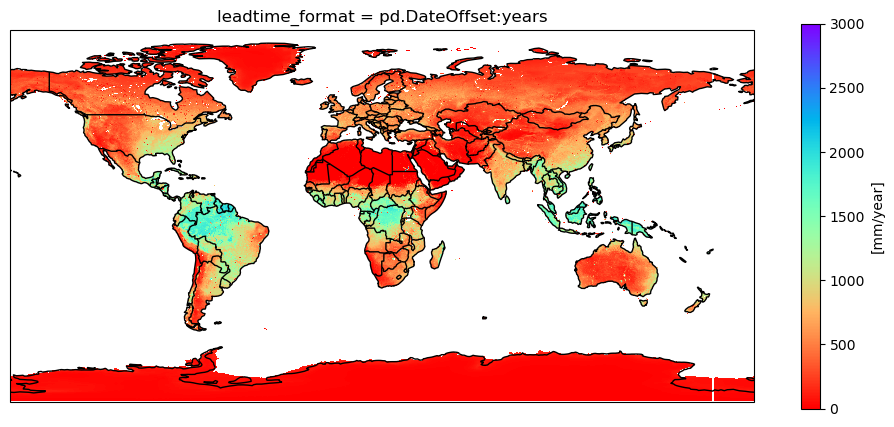

In [36]:
ax = aet.create_plot(central_longitude=20, figsize=(12,5))

cmap = 'rainbow_r'
fig = aet.plot_mean(ax=ax, coastline=True, borders=True, colorbar=True,
                  colorbar_label=f'[{aet.units}]', cmap=cmap, central_longitude=20, central_latitude=0, vmin=0, vmax=3000)

## Zoom in to your location
You can zoom in to your location by using the crop function.  
`.getCropped(from_lat=80, to_lat=120, from_lon=0, to_lon=90)`

Start by specifying the WGS 84 coordinates of the center of your catchment below (Latitude and Longitude).  
Shanghai can be an example:  
31.2 N and 121.4 E

In [37]:
lat = 31.2
lon = 121.4

In [38]:
cropped_aet = aet.getCropped(from_lat=lat-20, to_lat=lat+20, from_lon=lon-20, to_lon=lon+20)

C:\Users\zepedro\AppData\Local\Temp\ipykernel_58388\732069915.py:1: DeprecationWarning: getCropped() is deprecated and will be removed in a future release; call get_cropped() directly instead.
  cropped_aet = aet.getCropped(from_lat=lat-20, to_lat=lat+20, from_lon=lon-20, to_lon=lon+20)


Cropping meteorology...
    Done.


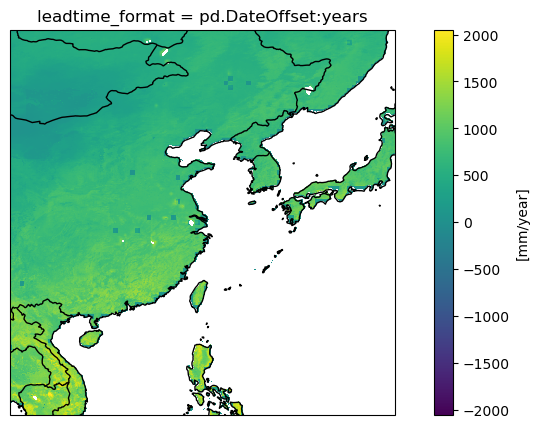

In [39]:
ax = cropped_aet.create_plot(central_longitude=20, figsize=(10,5))

cmap = 'viridis'
fig = cropped_aet.plot_mean(ax=ax, coastline=True, borders=True, colorbar=True,
                  colorbar_label=f'[{aet.units}]', cmap=cmap, central_longitude=20, central_latitude=0)

## You can read several years at once, get data for the chosen coordinates, and join the resulting time series
To accomplish this, we use the `.get_values_from_latlon()` function in a loop that goes through all the AET files from gleam.   
The results, stored in the `aet_series_` variable, are then "appended" to a list (`aet_series`) with the `.append()` function.

The results are then joint together with the `pd.concat()` function from `pandas`.  
You may find them in the `aet_series_all` variable.

Download the base files here:  
https://fenix.tecnico.ulisboa.pt/disciplinas/HRH/2024-2025/1-semestre/assignements  

- AET_GLEAM_v4.2b_YR.zip (actual evapotranspiration)
- PET_GLEAM_v4.2b_YR.zip (actual evapotranspiration)

<span style="color:red;">⚠️ Important! You must upload the contents of the zip files to the correct folders in order to do this online.</span>


In [40]:
gleam_files_path = Path(r'./additional/AET')

aet_series = []
files = [f for f in gleam_files_path.glob('*.nc')]
files.sort()
for f0 in files:
    print(f0.name)
    
    tmp = read_gleam(f0)
    aet_series_ = tmp.get_values_from_latlon(lat, lon)
    aet_series.append(aet_series_)

aet_series_all = pd.concat(aet_series, axis=0)
aet_series_all.columns = ['AET [mm/year]']
aet_series_all

E_2003_GLEAM_v4.2b_YR.nc
E_2004_GLEAM_v4.2b_YR.nc
E_2005_GLEAM_v4.2b_YR.nc
E_2006_GLEAM_v4.2b_YR.nc
E_2007_GLEAM_v4.2b_YR.nc
E_2008_GLEAM_v4.2b_YR.nc
E_2009_GLEAM_v4.2b_YR.nc
E_2010_GLEAM_v4.2b_YR.nc
E_2011_GLEAM_v4.2b_YR.nc
E_2012_GLEAM_v4.2b_YR.nc
E_2013_GLEAM_v4.2b_YR.nc
E_2014_GLEAM_v4.2b_YR.nc
E_2015_GLEAM_v4.2b_YR.nc
E_2016_GLEAM_v4.2b_YR.nc
E_2017_GLEAM_v4.2b_YR.nc
E_2018_GLEAM_v4.2b_YR.nc
E_2019_GLEAM_v4.2b_YR.nc
E_2020_GLEAM_v4.2b_YR.nc
E_2021_GLEAM_v4.2b_YR.nc
E_2022_GLEAM_v4.2b_YR.nc
E_2023_GLEAM_v4.2b_YR.nc
E_2024_GLEAM_v4.2b_YR.nc


,AET [mm/year]
production_datetime,
2003-12-31,610.940796
2004-12-31,649.172241
2005-12-31,618.627991
2006-12-31,631.685059
2007-12-31,634.878784
2008-12-31,638.768311
2009-12-31,648.479187
2010-12-31,635.739441
2011-12-31,615.995483


### The same for PET...

In [41]:
gleam_files_path = Path(r'./additional/PET')

pet_series = []
files = [f for f in gleam_files_path.glob('*.nc')]
files.sort()
for f0 in files:
    print(f0.name)
    
    tmp = read_gleam(f0)
    pet_series_ = tmp.get_values_from_latlon(lat, lon)
    pet_series.append(pet_series_)

pet_series_all = pd.concat(pet_series, axis=0)
pet_series_all.columns = ['PET [mm/year]']
pet_series_all

Ep_2003_GLEAM_v4.2b_YR.nc
Ep_2004_GLEAM_v4.2b_YR.nc
Ep_2005_GLEAM_v4.2b_YR.nc
Ep_2006_GLEAM_v4.2b_YR.nc
Ep_2007_GLEAM_v4.2b_YR.nc
Ep_2008_GLEAM_v4.2b_YR.nc
Ep_2009_GLEAM_v4.2b_YR.nc
Ep_2010_GLEAM_v4.2b_YR.nc
Ep_2011_GLEAM_v4.2b_YR.nc
Ep_2012_GLEAM_v4.2b_YR.nc
Ep_2013_GLEAM_v4.2b_YR.nc
Ep_2014_GLEAM_v4.2b_YR.nc
Ep_2015_GLEAM_v4.2b_YR.nc
Ep_2016_GLEAM_v4.2b_YR.nc
Ep_2017_GLEAM_v4.2b_YR.nc
Ep_2018_GLEAM_v4.2b_YR.nc
Ep_2019_GLEAM_v4.2b_YR.nc
Ep_2020_GLEAM_v4.2b_YR.nc
Ep_2021_GLEAM_v4.2b_YR.nc
Ep_2022_GLEAM_v4.2b_YR.nc
Ep_2023_GLEAM_v4.2b_YR.nc
Ep_2024_GLEAM_v4.2b_YR.nc


,PET [mm/year]
production_datetime,
2003-12-31,1158.562622
2004-12-31,1257.782227
2005-12-31,1215.132080
2006-12-31,1179.750854
2007-12-31,1173.355469
2008-12-31,1168.382935
2009-12-31,1150.692017
2010-12-31,1143.932007
2011-12-31,1140.280273


## Now we can plot and get the average
This is valid for a single point defined by WGS84 latitude and longitude.  
It makes sense that such a point lies at the center of your catchment

AET [mm/year]    646.02478
dtype: float32

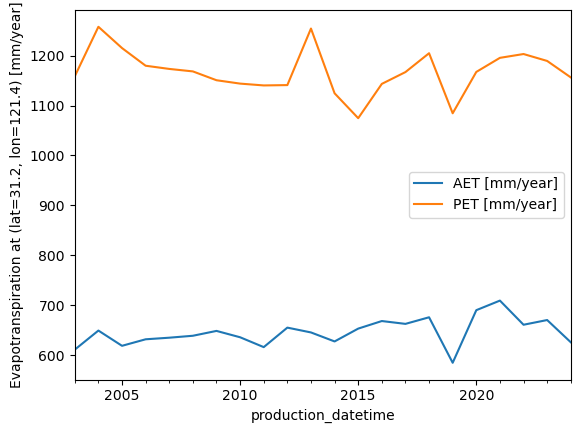

In [42]:
ax = aet_series_all.plot()
pet_series_all.plot(ax=ax)
ax.set_ylabel(f'Evapotranspiration at (lat={lat}, lon={lon}) [mm/year]')
aet_series_all.mean()


## If we want to export a raster that QGIS can open...
This (rather complicated code) saves all the information into a GeoTiff raster format that QGIS can read without any problems

In [43]:
gleam_files_path = Path(r'./additional/AET')
files = [f for f in gleam_files_path.glob('*.nc')]
files.sort()
joint = None
for f0 in files:
    tmp = read_gleam(f0)
    if joint:
        joint.join(tmp)
    else:
        joint = tmp
    
aet_xr = joint.to_xarray()

In [45]:
# Compute temporal mean
time_dim = aet_xr.dims[0]
da = aet_xr.mean(dim=time_dim, skipna=True).squeeze(drop=True)

lat = da["lat"].values
lon = da["lon"].values
arr = da.values.astype("float32")

# Handle 2D coordinate arrays (extract 1D vectors)
if lat.ndim == 2:
    lat = lat[:, 0]
    lon = lon[0, :]

# Ensure north->south and west->east orientation
if lat[0] < lat[-1]:
    lat = lat[::-1]
    arr = arr[::-1, :]
if lon[0] > lon[-1]:
    lon = lon[::-1]
    arr = arr[:, ::-1]

dlon = float(np.median(np.diff(lon)))
dlat = float(np.median(np.diff(lat)))

nodata = -9999.0
arr_out = np.where(np.isfinite(arr), arr, nodata)

out_tif = 'aet.tif'
driver = gdal.GetDriverByName("GTiff")
ds = driver.Create(str(out_tif), arr_out.shape[1], arr_out.shape[0], 1, gdal.GDT_Float32,
                   options=["COMPRESS=DEFLATE", "TILED=YES"])
ds.SetGeoTransform((float(lon[0] - dlon / 2), dlon, 0.0, float(lat[0] - dlat / 2), 0.0, dlat))
srs = osr.SpatialReference()
srs.ImportFromEPSG(4326)
ds.SetProjection(srs.ExportToWkt())
band = ds.GetRasterBand(1)
band.WriteArray(arr_out)
band.SetNoDataValue(nodata)
band.FlushCache()
ds = None

print(f"Saved: {out_tif}")


Saved: aet.tif


### And the same code for PET

In [46]:
gleam_files_path = Path(r'./additional/PET')
files = [f for f in gleam_files_path.glob('*.nc')]
files.sort()
joint = None
for f0 in files:
    tmp = read_gleam(f0)
    if joint:
        joint.join(tmp)
    else:
        joint = tmp
    
pet_xr = joint.to_xarray()

In [49]:
# Compute temporal mean
time_dim = pet_xr.dims[0]
da = pet_xr.mean(dim=time_dim, skipna=True).squeeze(drop=True)

lat = da["lat"].values
lon = da["lon"].values
arr = da.values.astype("float32")

# Handle 2D coordinate arrays (extract 1D vectors)
if lat.ndim == 2:
    lat = lat[:, 0]
    lon = lon[0, :]

# Ensure north->south and west->east orientation
if lat[0] < lat[-1]:
    lat = lat[::-1]
    arr = arr[::-1, :]
if lon[0] > lon[-1]:
    lon = lon[::-1]
    arr = arr[:, ::-1]

dlon = float(np.median(np.diff(lon)))
dlat = float(np.median(np.diff(lat)))

nodata = -9999.0
arr_out = np.where(np.isfinite(arr), arr, nodata)

out_tif = 'pet.tif'
driver = gdal.GetDriverByName("GTiff")
ds = driver.Create(str(out_tif), arr_out.shape[1], arr_out.shape[0], 1, gdal.GDT_Float32,
                   options=["COMPRESS=DEFLATE", "TILED=YES"])
ds.SetGeoTransform((float(lon[0] - dlon / 2), dlon, 0.0, float(lat[0] - dlat / 2), 0.0, dlat))
srs = osr.SpatialReference()
srs.ImportFromEPSG(4326)
ds.SetProjection(srs.ExportToWkt())
band = ds.GetRasterBand(1)
band.WriteArray(arr_out)
band.SetNoDataValue(nodata)
band.FlushCache()
ds = None

print(f"Saved: {out_tif}")

Saved: pet.tif
